In [36]:
import numpy as np
from scipy.optimize import minimize

In [37]:
class LinearSVR:
    
    def __init__(self, C=1.0, epsilon=0.1):
        self.C = C
        self.epsilon = epsilon

        self.w = None
        self.b = None

    def fit(self, X, y):

        n_samples, n_features = X.shape

        def objective(theta):

            w = theta[:n_features]
            xi = theta[n_features + 1:n_features + 1 + n_samples]
            xi_star = theta[
                n_features + 1 + n_samples:
                n_features + 1 + 2 * n_samples
            ]

            return (
                0.5 * np.dot(w, w)
                + self.C * np.sum(xi + xi_star)
            )

        def constraints(theta):

            w = theta[:n_features]
            b = theta[n_features]

            xi = theta[n_features + 1:n_features + 1 + n_samples]

            xi_star = theta[
                n_features + 1 + n_samples:
                n_features + 1 + 2 * n_samples
            ]

            predictions = X @ w + b
            constraint_upper = (
                self.epsilon
                + xi
                - (y - predictions)
            )
            constraint_lower = (
                self.epsilon
                + xi_star
                - (predictions - y)
            )

            return np.concatenate([
                constraint_upper,
                constraint_lower
            ])
        theta0 = np.zeros(
            n_features + 1 + 2 * n_samples
        )
        bounds = (
            [(None, None)] * (n_features + 1)
            + [(0, None)] * (2 * n_samples)
        )

        result = minimize(
            objective,
            theta0,
            method="SLSQP",
            bounds=bounds,
            constraints={
                "type": "ineq",
                "fun": constraints
            },
            options={
                "ftol": 1e-8,
                "maxiter": 2000
            }
        )

        if not result.success:
            raise RuntimeError(result.message)

        theta = result.x

        self.w = theta[:n_features]
        self.b = theta[n_features]

        return self

    def predict(self, X):

        return X @ self.w + self.b

In [38]:
from sklearn.datasets import make_regression

X, y = make_regression(
    n_samples=100,
    n_features=1,
    n_informative=1,
    noise=15,
    bias=10,
    random_state=42
)

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [40]:
C = 10
epsilon = 0.1

scratch_svr = LinearSVR(
    C=C,
    epsilon=epsilon
)

scratch_svr.fit(X_train, y_train)

scratch_pred = scratch_svr.predict(X_test)

In [41]:
from sklearn.svm import SVR
sklearn_svr = SVR(
    kernel="linear",
    C=C,
    epsilon=epsilon
)

sklearn_svr.fit(X_train, y_train)

sklearn_pred = sklearn_svr.predict(X_test)

In [42]:
from sklearn.metrics import mean_squared_error, r2_score

print("Scratch SVR")
print("MSE :", mean_squared_error(y_test, scratch_pred))
print("R2  :", r2_score(y_test, scratch_pred))

print("\nSklearn SVR")
print("MSE :", mean_squared_error(y_test, sklearn_pred))
print("R2  :", r2_score(y_test, sklearn_pred))

Scratch SVR
MSE : 244.6791438514121
R2  : 0.8687139127619444

Sklearn SVR
MSE : 244.67914005095795
R2  : 0.8687139148011324


In [43]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Linear Regression")
print("MSE :", mean_squared_error(y_test, lr_pred))
print("R2  :", r2_score(y_test, lr_pred))

Linear Regression
MSE : 234.45500969670806
R2  : 0.8741998178842183


In [44]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Linear Regression")
print("MSE :", mean_squared_error(y_test, lr_pred))
print("R2  :", r2_score(y_test, lr_pred))

Linear Regression
MSE : 234.45500969670806
R2  : 0.8741998178842183


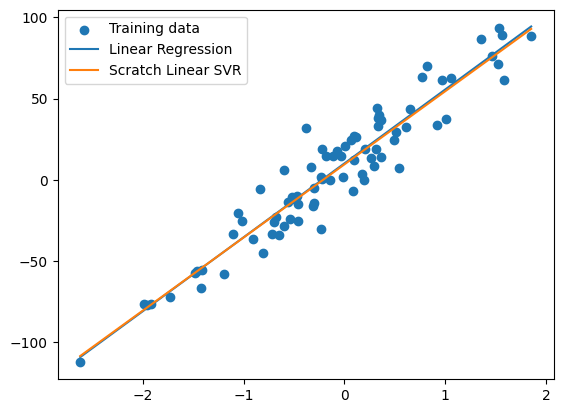

In [45]:
import matplotlib.pyplot as plt

X_plot = np.linspace(
    X.min(),
    X.max(),
    500
).reshape(-1, 1)

plt.scatter(
    X_train,
    y_train,
    label="Training data"
)

plt.plot(
    X_plot,
    lr.predict(X_plot),
    label="Linear Regression"
)

plt.plot(
    X_plot,
    scratch_svr.predict(X_plot),
    label="Scratch Linear SVR"
)

plt.legend()
plt.show()